# Comparing RC and generalized two terminal SSN linear circuit simulations in SP Ph1 domain
### Comparing SP domain simulations of Ph1 linear circuits built from Resistive Companion (RC) component models against the same linear circuits build from generalized two terminal SSN (State Space Nodal) component models.

## Run C++ example: RLC circuit

In [15]:
import os
import subprocess

# %matplotlib widget

name = "SP_Ph1_General2TerminalSSN"

dpsim_path = (
    subprocess.Popen(["git", "rev-parse", "--show-toplevel"], stdout=subprocess.PIPE)
    .communicate()[0]
    .rstrip()
    .decode("utf-8")
)

path_exec = dpsim_path + "/build/dpsim/examples/cxx/"
sim = subprocess.Popen(
    [path_exec + name], stdout=subprocess.PIPE, stderr=subprocess.STDOUT
)
print(sim.communicate()[0].decode())

[16:56:37.544627 SP_Ph1_VS_rlc_RC info] Initialize simulation: SP_Ph1_VS_rlc_RC
[16:56:37.544773 MnaSolverFactory info] creating KLUAdapter solver implementation
Nonzero entries:
(0.666667,0) (-0.666667,1) (1,3) (0,4) (0,5) (-0,7) (-0.666667,0) (0.666667,1) (0,2) (0,4) (0.159155,5) (-0.159155,6) (0,1) (0,2) (-0.159155,5) (-24.9736,6) (1,0) (-0,4) (0,0) (0,1) (0,3) (0.666667,4) (-0.666667,5) (1,7) (0,0) (-0.159155,1) (0.159155,2) (-0.666667,4) (0.666667,5) (0,6) (0.159155,1) (24.9736,2) (0,5) (0,6) (0,0) (1,4) 

Outer pointers:
0 6 12 16 18 24 30 34  $

0.666667 -0.666667 0 1 0 0 0 -0 
-0.666667 0.666667 0 0 0 0.159155 -0.159155 0 
0 0 0 0 0 -0.159155 -24.9736 0 
1 0 0 0 -0 0 0 0 
0 0 0 0 0.666667 -0.666667 0 1 
0 -0.159155 0.159155 0 -0.666667 0.666667 0 0 
0 0.159155 24.9736 0 0 0 0 0 
0 0 0 0 1 0 0 0 

[16:56:37.545335 SP_Ph1_VS_rlc_RC info] Scheduling tasks.
[16:56:37.545672 SP_Ph1_VS_rlc_RC info] Scheduling done.
[16:56:37.545726 SP_Ph1_VS_rlc_RC info] Opening interfaces.
[16:56:37

### Load Results

In [16]:
from villas.dataprocessing.readtools import *
from villas.dataprocessing.timeseries import *
from villas.dataprocessing.timeseries import TimeSeries as ts
import matplotlib.pyplot as plt
import re
import numpy as np
import math

name = "SP_Ph1_VS_rlc"

work_dir = os.getcwd() + "/logs/"
path_logfile_VS_rlc_RC = work_dir + name + "_RC/" + name + "_RC" + ".csv"
ts_SP_Ph1_VS_rlc_RC = read_timeseries_dpsim(path_logfile_VS_rlc_RC)

path_logfile_VS_rlc_SSNsingleComps = (
    work_dir + name + "_SSNsingleComps/" + name + "_SSNsingleComps" + ".csv"
)
ts_SP_VS_rlc_SSNsingleComps = read_timeseries_dpsim(path_logfile_VS_rlc_SSNsingleComps)

path_logfile_VS_RLC_genSSNcombined = (
    work_dir + name + "_genSSNcombined/" + name + "_genSSNcombined" + ".csv"
)
ts_SP_Ph1_VS_RLC_genSSNcombined = read_timeseries_dpsim(
    path_logfile_VS_RLC_genSSNcombined
)

column number: 4
results length: 1001
real column names: []
complex column names: ['i12', 'v1', 'v2', 'v3']
column number: 4
results length: 1001
real column names: []
complex column names: ['i12', 'v1', 'v2', 'v3']
column number: 2
results length: 1001
real column names: []
complex column names: ['i12', 'v1']


## Plot results

Text(0, 0.5, 'RLC Current [A]')

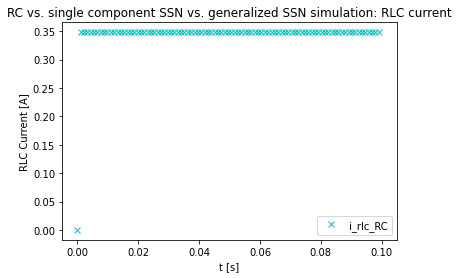

In [ ]:
plt.close("all")
fig1 = plt.figure()

plt.plot(
    ts_SP_Ph1_VS_rlc_RC["i12"].time,
    np.abs(ts_SP_Ph1_VS_rlc_RC["i12"].values),
    "cx",
    markevery=11,
    label="i_rlc_RC",
)
plt.plot(
    ts_SP_VS_rlc_SSNsingleComps["i12"].time,
    np.abs(ts_SP_VS_rlc_SSNsingleComps["i12"].values),
    "bx",
    markevery=13,
    label="i_rlc_SSN_single",
)

plt.plot(
    ts_SP_Ph1_VS_RLC_genSSNcombined["i12"].time,
    np.abs(ts_SP_Ph1_VS_RLC_genSSNcombined["i12"].values),
    "rx",
    markevery=17,
    label="i_rlc_SSN_combined",
)


plt.legend(loc=4)

plt.title("RC vs. single component SSN vs. generalized SSN simulation: RLC current")
plt.xlabel("t [s]")
plt.ylabel("RLC Current [A]")

## Assert

In [ ]:
# ''epsilon = 1e-12

# # Capacitor circuit
# assert (
#     np.max(
#         ts_EMT_Ph1_C1R1Vs_RC["v_c_rc"].values
#         - ts_EMT_Ph1_C1R1Vs_generalizedSSN["v_c_genSSN"].values
#     )
#     < epsilon
# )
# assert (
#     np.max(
#         ts_EMT_Ph1_C1R1Vs_RC["i_c_rc"].values
#         - ts_EMT_Ph1_C1R1Vs_generalizedSSN["i_c_genSSN"].values
#     )
#     < epsilon
# )

# # Inductor circuit
# assert (
#     np.max(
#         ts_EMT_Ph1_L1R1Vs_RC["v_l_rc"].values
#         - ts_EMT_Ph1_L1R1Vs_generalizedSSN["v_l_genSSN"].values
#     )
#     < epsilon
# )
# assert (
#     np.max(
#         ts_EMT_Ph1_L1R1Vs_RC["i_l_rc"].values
#         - ts_EMT_Ph1_L1R1Vs_generalizedSSN["i_l_genSSN"].values
#     )
#     < epsilon
# )